In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict
import glob
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

# stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'dont','didnt','doesnt','would','could','one','get','got',
    'really','also','even','much','many','well','make','made','still',
    'thing','things','something','anything','everything','way','lot',
    'first','second','third','time','day','week','month','year',
    'ive','im','youre','theyre','cant','wont','couldnt','wouldnt',
    'product','item','order','ordered','buy','bought', 'isnt',
    'purchase','purchased','using','use','used', 'looking','look',
    'said', 'shoe', 'box', 'came', 'work', 'put', 'door'
}

stop_words = set(stopwords.words('english')).union(custom_stopwords)


base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"n't", " not", text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens
def get_word_freq(token_series):
    all_words = []
    for tokens in token_series:
        all_words.extend(tokens)
    return Counter(all_words)

all_products=[]
reviews_per_brand = defaultdict(int)
for year_folder in year_folders:
    year = int(year_folder.name.split("=")[1])
    for file in year_folder.glob("*.parquet"):
        df = pd.read_parquet(file, columns=["parent_asin", "asin", "brand", "rating", 'price', "review"]) #rating here is reviewer's rating
        df = df.dropna(subset=["parent_asin", "asin", "brand", "rating", 'price',"review"])
        df["review"]=df["review"].astype(str).str.strip()
        df["brand"]=df["brand"].astype(str).str.strip()
        not_brand = {"", "unknown", "generic", "unbranded", "none", "nan", "/n"}
        df = df[~df["brand"].str.lower().isin(not_brand)]
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
        df = df[df["price"] > 0]
        df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
        df = df[(df["rating"] > 0) & (df["rating"] <= 5)]
        df['year']=year
        all_products.append(df)
products=pd.concat(all_products, ignore_index=True)
products["price_segment"] = np.select([products["price"] < 100,(products["price"] >= 100) & (products["price"] <= 1000),products["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
# products.head(10)
# print(products[products["price_segment"] == "luxury"].head(5))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
durability_words = ["break", "broken", "broke", "defect", "damaged",
                    "snap", "crack", 'snapped', 'fell apart', 'defective',
                    'faulty', 'stopped working', 'does not work', 'cheaply made',
                    'poor quality', 'flimsy', 'fragile']
# pattern = r'\b(' + '|'.join(durability_words) + r')\b'
pattern = r'\b(?:' + '|'.join(map(re.escape, durability_words)) + r')\b'

products['durability_flag'] = products['review'].str.contains(pattern, case=False, na=False)

In [4]:
product_stats = (products.groupby("parent_asin").agg(
    avg_rating=("rating", "mean"),
    total_reviews=("rating", "count"),
    durability_rate=("durability_flag", "mean"),
    price=("price", "median")).reset_index())

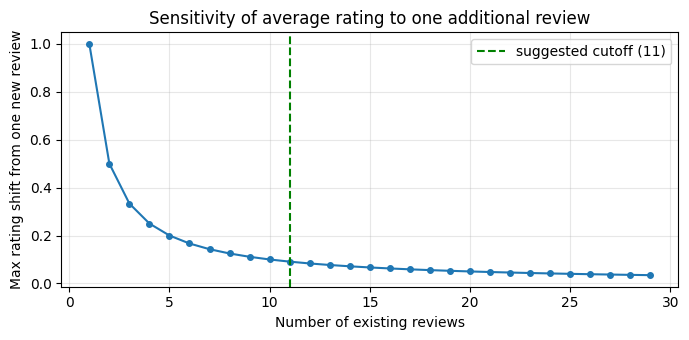

min_reviews >=  3: 28,337 products(56.4% retained)
min_reviews >=  5: 21,558 products(42.9% retained)
min_reviews >= 10: 14,378 products(28.6% retained)
min_reviews >= 20:  8,985 products(17.9% retained)


In [5]:
#sensitivity analysis
#Simulate how much a single new review shifts the average, as a function of how many reviews already exist
review_counts = np.arange(1, 30)
impact = 1 / review_counts

deltas = np.abs(np.diff(impact))
elbow = np.argmax(deltas < 0.01) + 1
best_cutoff = review_counts[elbow]

plt.figure(figsize=(7, 3.5))
plt.plot(review_counts, impact, marker='o', markersize=4)
plt.axvline(best_cutoff, color='green', linestyle='--',label=f'suggested cutoff ({best_cutoff})')
plt.xlabel("Number of existing reviews")
plt.ylabel("Max rating shift from one new review")
plt.title("Sensitivity of average rating to one additional review")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#what % of products survive each threshold?
for threshold in [3, 5, 10, 20]:
    n = (product_stats["total_reviews"] >= threshold).sum()
    pct = n / len(product_stats) * 100
    print(f"min_reviews >= {threshold:2d}: {n:6,} products({pct:.1f}% retained)")

In [ ]:
#The sensitivity analysis found that at n=11, one review shifts the average
#by at most 0.09 stars below the 0.1-star threshold where noise becomes meaningful.
#Products with fewer than 11 reviews are excluded.

In [6]:
product_stats["log_price"] = np.log1p(product_stats["price"])
product_stats["price_segment"] = np.select([product_stats["price"] < 100,(product_stats["price"] >= 100) & (product_stats["price"] <= 1000),product_stats["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
product_stats = product_stats[product_stats["total_reviews"] >= 11].copy()
product_stats.head()

,parent_asin,avg_rating,total_reviews,durability_rate,price,log_price,price_segment
2,8742240611,4.400000,15,0.133333,9.88,2.386926,cheap
5,B0000AX6DV,4.820513,39,0.076923,84.99,4.454231,cheap
10,B0000E1VVX,4.464286,28,0.035714,29.15,3.406185,cheap
13,B00011V8YU,4.408163,49,0.081633,67.49,4.226688,cheap
18,B00015CELM,4.633333,30,0.033333,93.99,4.553772,cheap


In [7]:
import statsmodels.api as sm

X = product_stats[["durability_rate", "log_price", "total_reviews"]]
X = sm.add_constant(X)

y = product_stats["avg_rating"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     2172.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        13:09:27   Log-Likelihood:                -7945.4
No. Observations:               13524   AIC:                         1.590e+04
Df Residuals:                   13520   BIC:                         1.593e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1981      0.016    2

In [8]:
import scipy.stats as stats

#plot OLS diagnostic charts
#residuals vs fitted, Q-Q plot, scale-location, and residuals vs leverage
def plot_regression_diagnostics(model, title_suffix=""):

    fitted = model.fittedvalues
    residuals = model.resid
    std_resid = (residuals - residuals.mean()) / residuals.std()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"OLS diagnostics — {title_suffix}", fontsize=12)

    axes[0].scatter(fitted, residuals, alpha=0.2, s=10)
    axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')
    axes[0].set_xlabel("Fitted values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title("Residuals vs Fitted")

    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title("Q-Q plot")

    axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.2, s=10)
    axes[2].set_xlabel("Fitted values")
    axes[2].set_ylabel("sqrt(|Standardised residuals|)")
    axes[2].set_title("Scale-Location")

    plt.tight_layout()
    plt.show()

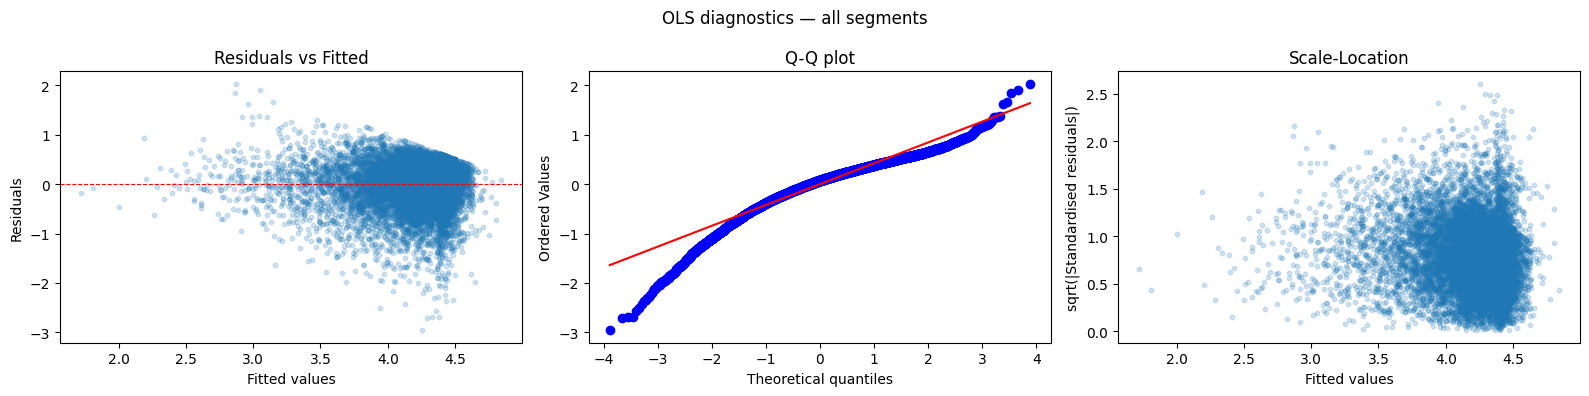


SEGMENT: CHEAP
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     2091.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        13:09:40   Log-Likelihood:                -7625.4
No. Observations:               12902   AIC:                         1.526e+04
Df Residuals:                   12898   BIC:                         1.529e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.0847

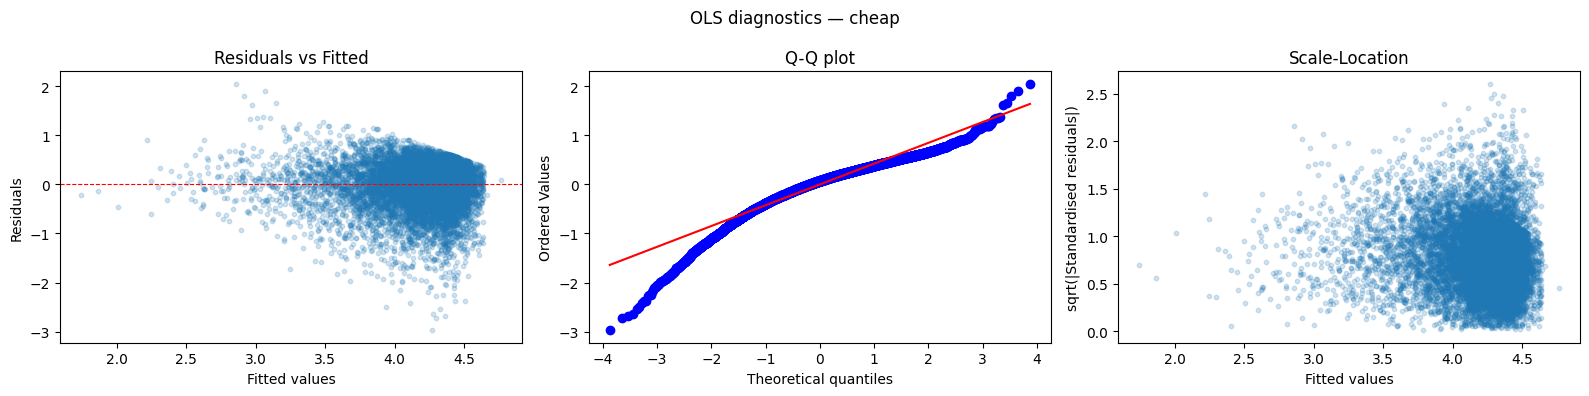


SEGMENT: MID
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     126.8
Date:                Thu, 14 May 2026   Prob (F-statistic):           7.64e-64
Time:                        13:09:41   Log-Likelihood:                -260.50
No. Observations:                 614   AIC:                             529.0
Df Residuals:                     610   BIC:                             546.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.7406  

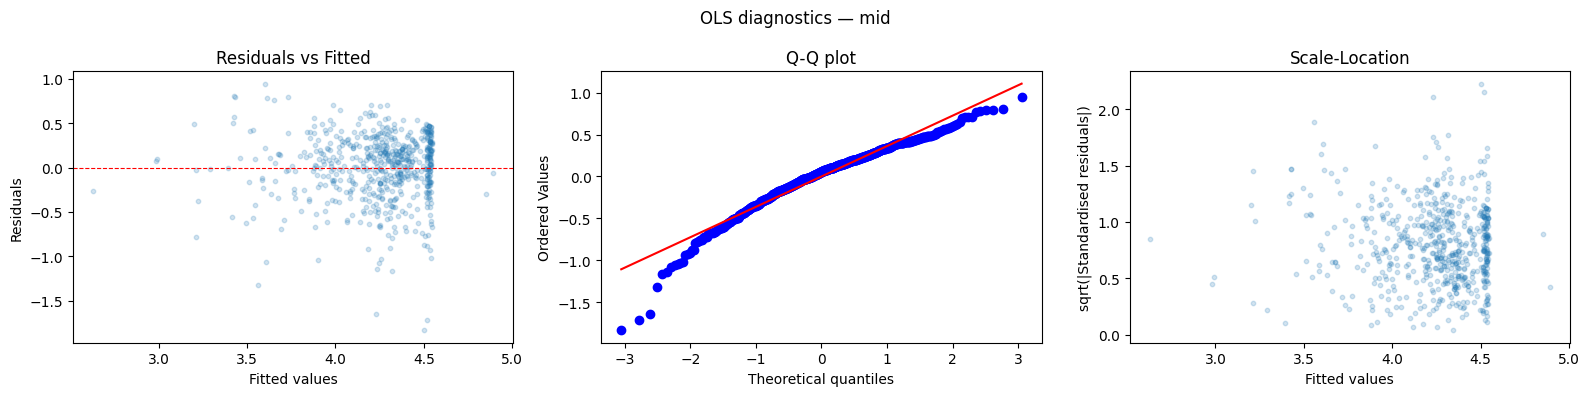


SEGMENT: LUXURY
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1.381
Date:                Thu, 14 May 2026   Prob (F-statistic):              0.370
Time:                        13:09:42   Log-Likelihood:                 2.4681
No. Observations:                   8   AIC:                             3.064
Df Residuals:                       4   BIC:                             3.381
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.030

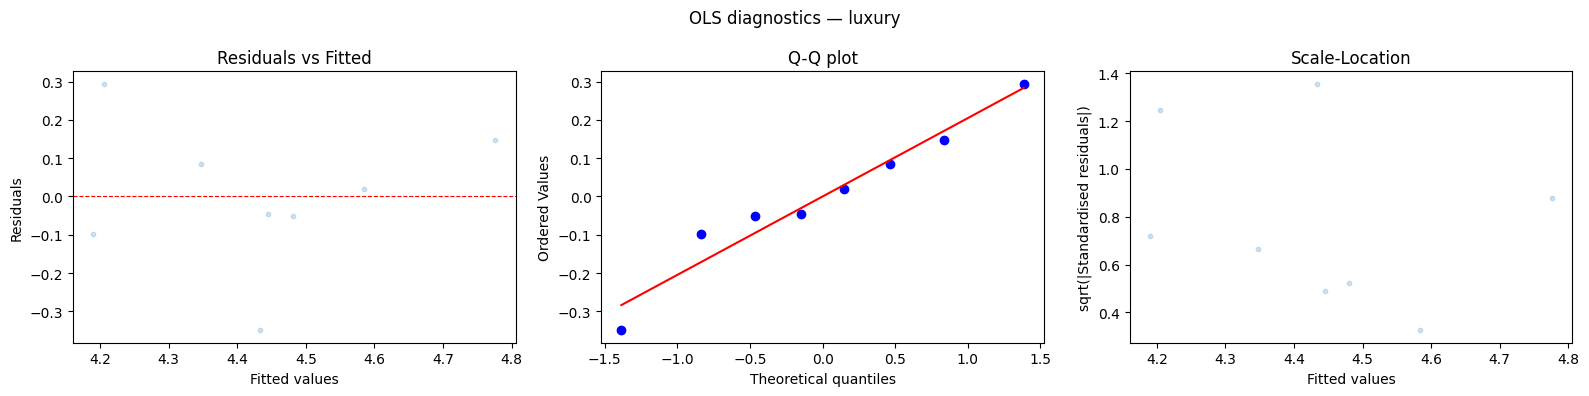

In [9]:
plot_regression_diagnostics(model, title_suffix="all segments")

for segment in ["cheap", "mid", "luxury"]:
    subset = product_stats[product_stats["price_segment"] == segment]
    X = subset[["durability_rate", "log_price", "total_reviews"]]
    X = sm.add_constant(X)
    y = subset["avg_rating"]
    model_seg = sm.OLS(y, X).fit()
    print(f"\n{'='*40}")
    print(f"SEGMENT: {segment.upper()}")
    print(model_seg.summary())
    plot_regression_diagnostics(model_seg, title_suffix=segment)

<Axes: xlabel='durability_rate', ylabel='avg_rating'>

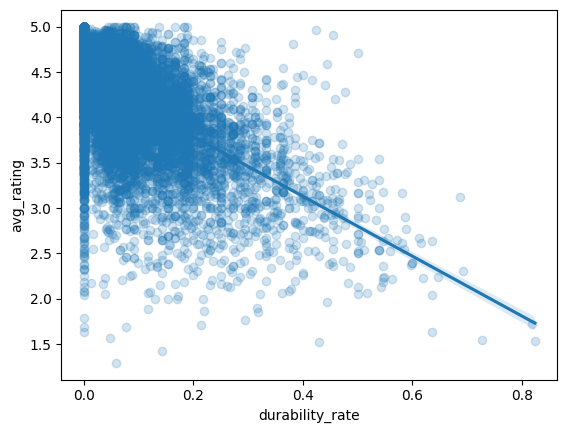

In [10]:
sns.regplot(
    data=product_stats,
    x="durability_rate",
    y="avg_rating",
    scatter_kws={"alpha": 0.2})

In [11]:
for segment in ["cheap", "mid", "luxury"]:
    subset = product_stats[product_stats["price_segment"] == segment]

    X = subset[["durability_rate", "total_reviews"]]
    X = sm.add_constant(X)

    y = subset["avg_rating"]

    model = sm.OLS(y, X).fit()

    print(f"{segment.upper()}")
    print(model.summary())

CHEAP
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     2905.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        13:10:19   Log-Likelihood:                -7782.6
No. Observations:               12902   AIC:                         1.557e+04
Df Residuals:                   12899   BIC:                         1.559e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.4406      0.00

In [13]:
# #compare complains types

size_words = [
    "too small", "too big", "too large", "too tight", "too loose",
    "didn't fit", "doesn't fit", "not fit", "wrong size",
    "smaller than expected", "larger than expected"
]

size_pattern = r'\b(?:' + '|'.join(map(re.escape, size_words)) + r')\b'
products["size_flag"] = products["review"].str.contains(size_pattern, case=False, na=False)



In [14]:
appearance_words = [
    "cheap looking", "looks cheap", "looked cheap",
    "ugly", "bad looking", "looks fake",
    "look fake", "fake looking", "not as pictured",
    "not like picture", "different from picture",
    "cheaply made", "looks different"
]

appearance_pattern = r'\b(?:' + '|'.join(map(re.escape, appearance_words)) + r')\b'

products["appearance_flag"] = products["review"].str.contains(appearance_pattern, case=False, na=False)

In [15]:
color_words = [
    "color faded", "faded", "color changed",
    "not same color", "different color",
    "color off", "color wrong"
]

color_pattern = r'\b(?:' + '|'.join(map(re.escape, color_words)) + r')\b'
products["color_flag"] = products["review"].str.contains(color_pattern, case=False, na=False)

In [16]:
product_stats_multi = (
    products.groupby("parent_asin")
    .agg(avg_rating=("rating", "mean"),
         total_reviews=("rating", "count"),
         durability_rate=("durability_flag", "mean"),
         size_rate=("size_flag", "mean"),
         appearance_rate=("appearance_flag", "mean"),
         color_rate=("color_flag", "mean"),
         price=("price", "median")).reset_index())

product_stats_multi["log_price"] = np.log1p(product_stats_multi["price"])
product_stats_multi["price_segment"] = np.select([product_stats_multi["price"] < 100,(product_stats_multi["price"] >= 100) & (product_stats_multi["price"] <= 1000),product_stats_multi["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
product_stats_multi = product_stats_multi[product_stats_multi["total_reviews"] >= 11]

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(X_df):
    X_no_const = X_df.drop(columns=["const"], errors="ignore")
    vif_data = pd.DataFrame({
        "Feature": X_no_const.columns,
        "VIF": [variance_inflation_factor(X_no_const.values, i)
                for i in range(X_no_const.shape[1])]
    }).sort_values("VIF", ascending=False)
    return vif_data

X_full = product_stats_multi[["durability_rate", "size_rate",
                               "appearance_rate", "color_rate",
                               "log_price", "total_reviews"]]
X_full = sm.add_constant(X_full)
print(check_vif(X_full))

           Feature       VIF
4        log_price  2.201558
0  durability_rate  1.735246
1        size_rate  1.412498
2  appearance_rate  1.284256
5    total_reviews  1.145363
3       color_rate  1.042218


In [18]:
X = product_stats_multi[[
    "durability_rate",
    "size_rate",
    "appearance_rate",
    "color_rate",
    "log_price",
    "total_reviews"
]]

X = sm.add_constant(X)
y = product_stats_multi["avg_rating"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     1290.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        13:11:36   Log-Likelihood:                -7543.2
No. Observations:               13524   AIC:                         1.510e+04
Df Residuals:                   13517   BIC:                         1.515e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.2931      0.016    2

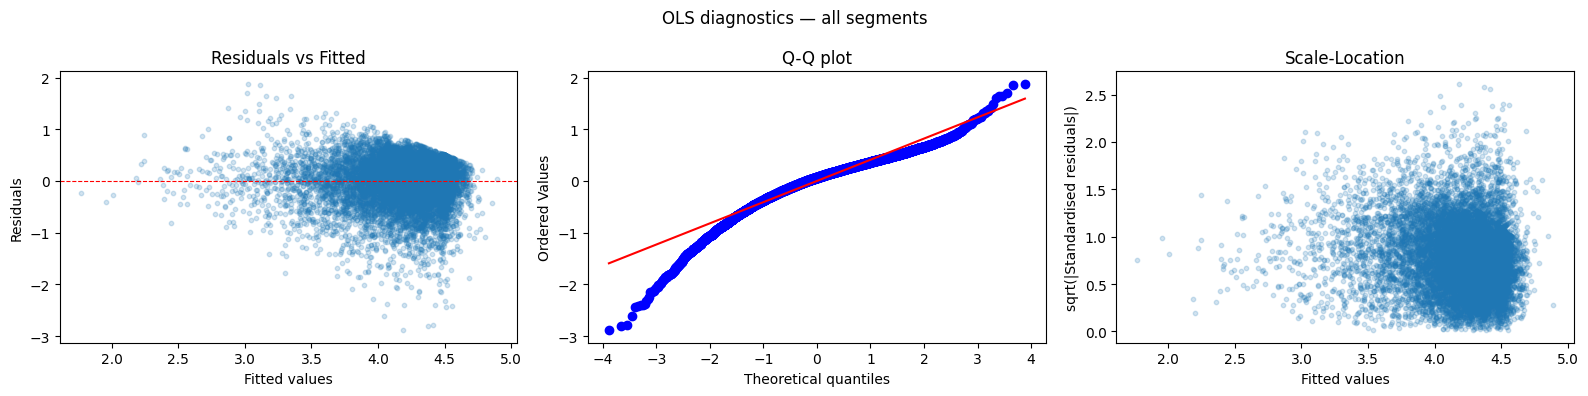


SEGMENT: CHEAP
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     1401.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        13:11:41   Log-Likelihood:                -7382.8
No. Observations:               12902   AIC:                         1.478e+04
Df Residuals:                   12896   BIC:                         1.482e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.5219

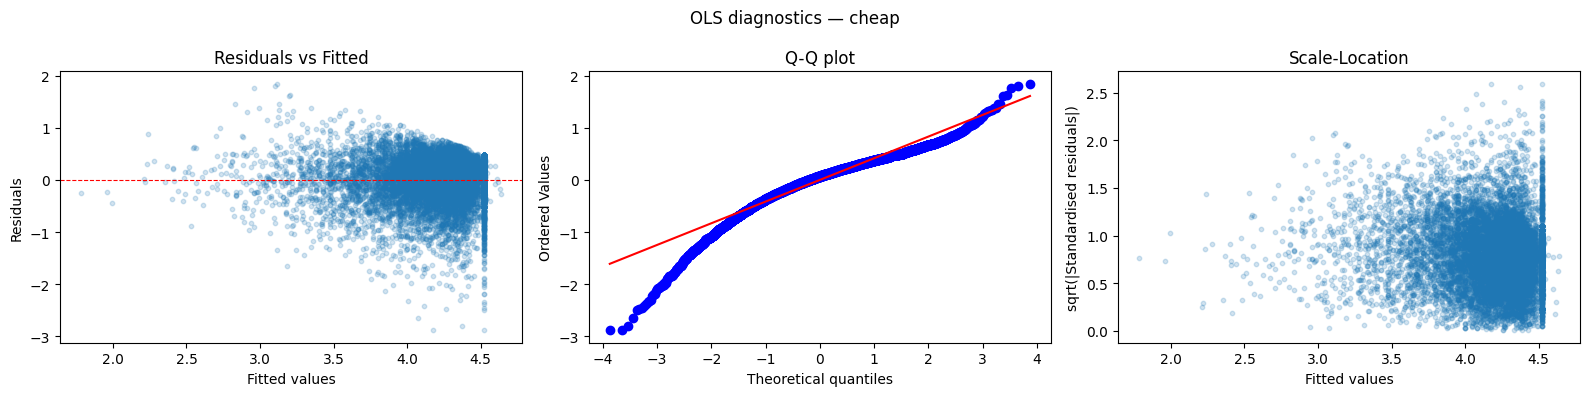


SEGMENT: MID
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     86.79
Date:                Thu, 14 May 2026   Prob (F-statistic):           8.22e-69
Time:                        13:11:41   Log-Likelihood:                -243.93
No. Observations:                 614   AIC:                             499.9
Df Residuals:                     608   BIC:                             526.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.5601  

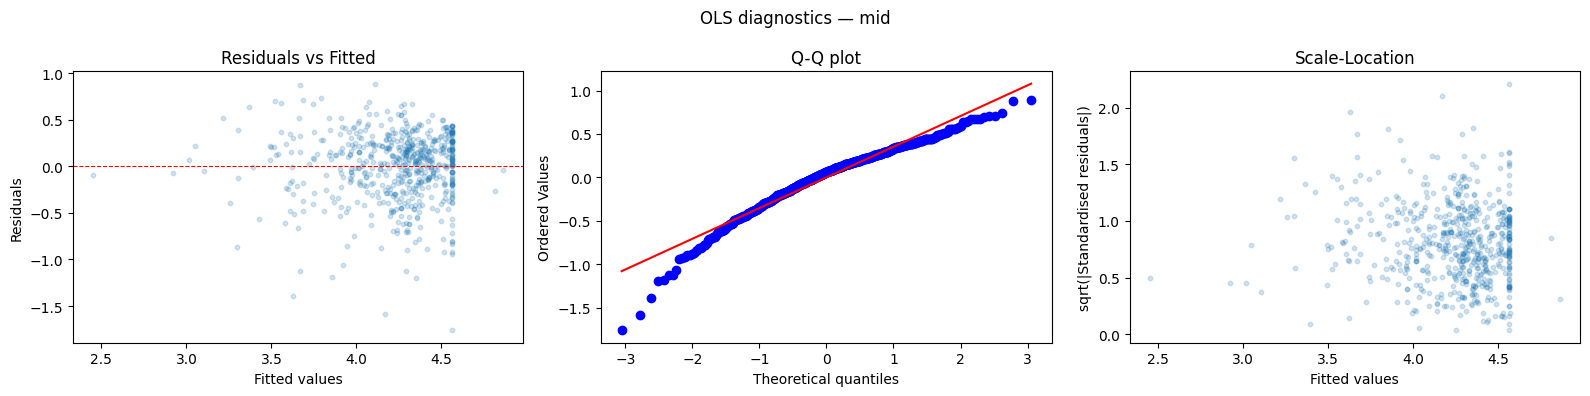


SEGMENT: LUXURY
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                 -0.419
Method:                 Least Squares   F-statistic:                    0.4836
Date:                Thu, 14 May 2026   Prob (F-statistic):              0.753
Time:                        13:11:42   Log-Likelihood:                 1.6154
No. Observations:                   8   AIC:                             6.769
Df Residuals:                       3   BIC:                             7.166
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.468

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


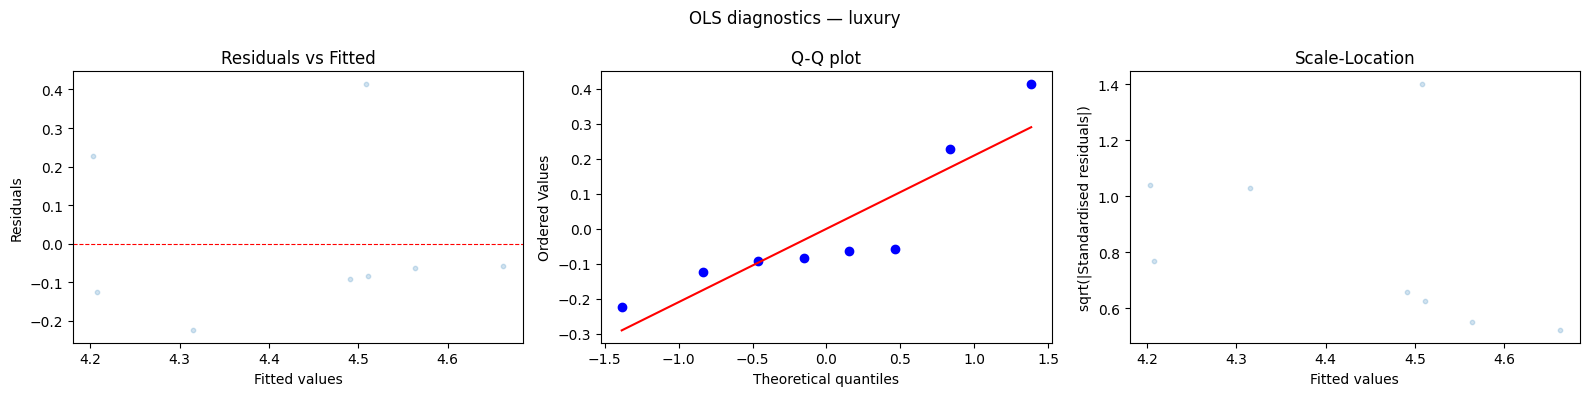

In [19]:
plot_regression_diagnostics(model, title_suffix="all segments")

for segment in ["cheap", "mid", "luxury"]:
    subset = product_stats_multi[product_stats_multi["price_segment"] == segment]
    X = subset[["durability_rate", "size_rate", "appearance_rate",
                "color_rate", "total_reviews"]]
    X = sm.add_constant(X)
    y = subset["avg_rating"]
    model_seg = sm.OLS(y, X).fit()
    print(f"\n{'='*40}")
    print(f"SEGMENT: {segment.upper()}")
    print(model_seg.summary())
    plot_regression_diagnostics(model_seg, title_suffix=segment)

In [20]:
results = []

for segment in ["cheap", "mid", "luxury"]:
    subset = product_stats_multi[product_stats_multi["price_segment"] == segment]

    X = subset[[
        "durability_rate",
        "size_rate",
        "appearance_rate",
        "color_rate",
        "total_reviews"
    ]]
    X = sm.add_constant(X)
    y = subset["avg_rating"]

    model_seg = sm.OLS(y, X).fit()
    print(model_seg.summary())

    results.append({
        "segment": segment,
        "durability": model_seg.params["durability_rate"],
        "size": model_seg.params["size_rate"],
        "appearance": model_seg.params["appearance_rate"],
        "color": model_seg.params["color_rate"]
    })

pd.DataFrame(results)

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     1401.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        13:11:56   Log-Likelihood:                -7382.8
No. Observations:               12902   AIC:                         1.478e+04
Df Residuals:                   12896   BIC:                         1.482e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.5219      0.006    7

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


,segment,durability,size,appearance,color
0,cheap,-3.132663,-2.132661,-2.740135,-1.729151
1,mid,-3.275363,-0.706717,-3.539027,-0.865545
2,luxury,-2.052435,0.370016,-7.999740,0.000000


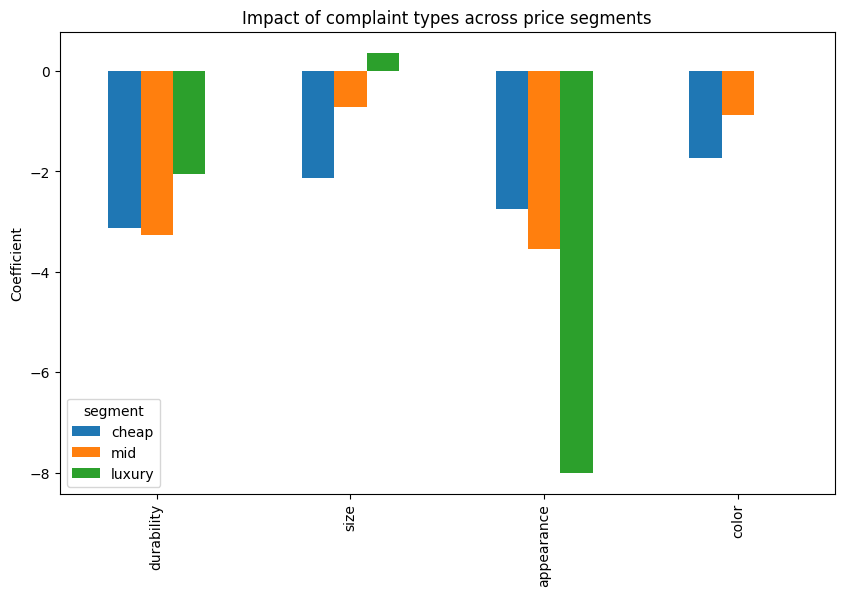

In [21]:
df_plot = pd.DataFrame(results).set_index("segment")

df_plot.T.plot(kind="bar", figsize=(10,6))
plt.title("Impact of complaint types across price segments")
plt.ylabel("Coefficient")
plt.show()